# Modulo 3 - Filtro Hodrick-Prescott y pasajeros de avion en Python

Curso: **Series Temporales con R y Python** (Frogames Formacion).

Codigo de acompanamiento de la leccion `03-caracteristicas-fundamentales/04-hp-filter-y-pasajeros-de-avion`.

Dos datasets clasicos en este notebook: el PIB real trimestral de EE.UU. (dataset `macrodata` que trae `statsmodels` de fabrica, 1959-2009) para el filtro Hodrick-Prescott, y los pasajeros de avion mensuales 1949-1960 (`AirPassengers`, el mismo dataset base de R, exportado a CSV) para la descomposicion clasica con estacionalidad real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.seasonal import seasonal_decompose

macro = sm.datasets.macrodata.load_pandas().data
idx = pd.PeriodIndex.from_fields(year=macro.year.astype(int), quarter=macro.quarter.astype(int), freq='Q')
macro.index = idx.to_timestamp()
print(macro.shape)
macro[['realgdp']].head()

(203, 14)


,realgdp
1959-01-01,2710.349
1959-04-01,2778.801
1959-07-01,2775.488
1959-10-01,2785.204
1960-01-01,2847.699


## Filtro Hodrick-Prescott

El filtro HP separa una serie en dos componentes: un ciclo (`gdp_cycle`) y una tendencia suavizada (`gdp_trend`), controlado por el parametro `lambda` (1600 es el valor estandar para datos trimestrales). Es una alternativa clasica a `seasonal_decompose` cuando lo que interesa es la tendencia de largo plazo, no la estacionalidad.

In [2]:
gdp_cycle, gdp_trend = hpfilter(macro['realgdp'], lamb=1600)
macro['trend'] = gdp_trend
macro['cycle'] = gdp_cycle
macro[['realgdp', 'trend']].tail()

,realgdp,trend
2008-07-01,13324.600,13222.581545
2008-10-01,13141.920,13249.189472
2009-01-01,12925.410,13274.457706
2009-04-01,12901.504,13299.061073
2009-07-01,12990.341,13323.456243


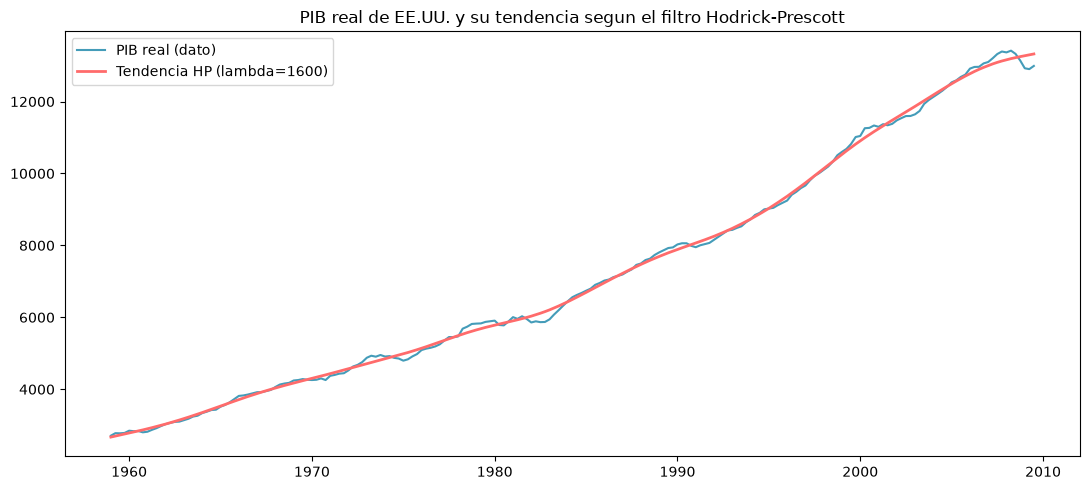

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(macro.index, macro['realgdp'], label='PIB real (dato)', color='#449cb9')
ax.plot(macro.index, macro['trend'], label='Tendencia HP (lambda=1600)', color='#ff6b6b', linewidth=2)
ax.set_title('PIB real de EE.UU. y su tendencia segun el filtro Hodrick-Prescott')
ax.legend()
plt.tight_layout()
plt.savefig('hp_filter_full.png', dpi=130)
plt.show()

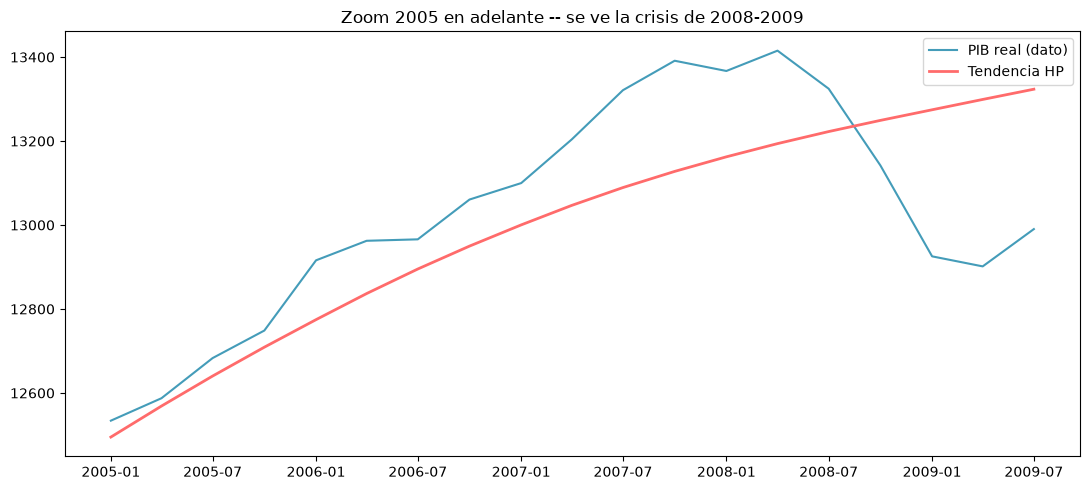

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
sub = macro['2005-01-01':]
ax.plot(sub.index, sub['realgdp'], label='PIB real (dato)', color='#449cb9')
ax.plot(sub.index, sub['trend'], label='Tendencia HP', color='#ff6b6b', linewidth=2)
ax.set_title('Zoom 2005 en adelante -- se ve la crisis de 2008-2009')
ax.legend()
plt.tight_layout()
plt.savefig('hp_filter_zoom.png', dpi=130)
plt.show()

## Pasajeros de avion: la serie clasica de estacionalidad real

A diferencia del S&P 500 (Leccion 02, donde la "estacionalidad" forzada con period=252 no significaba nada real), esta serie SI tiene estacionalidad genuina: mas gente vuela en verano y en Navidad. Mismo dataset que usa R (`AirPassengers`), exportado a CSV para que ambos lenguajes partan exactamente del mismo dato.

In [5]:
airline = pd.read_csv("AirPassengers.csv", index_col="month", parse_dates=True)
airline = airline.asfreq('MS')
airline.head()

,passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


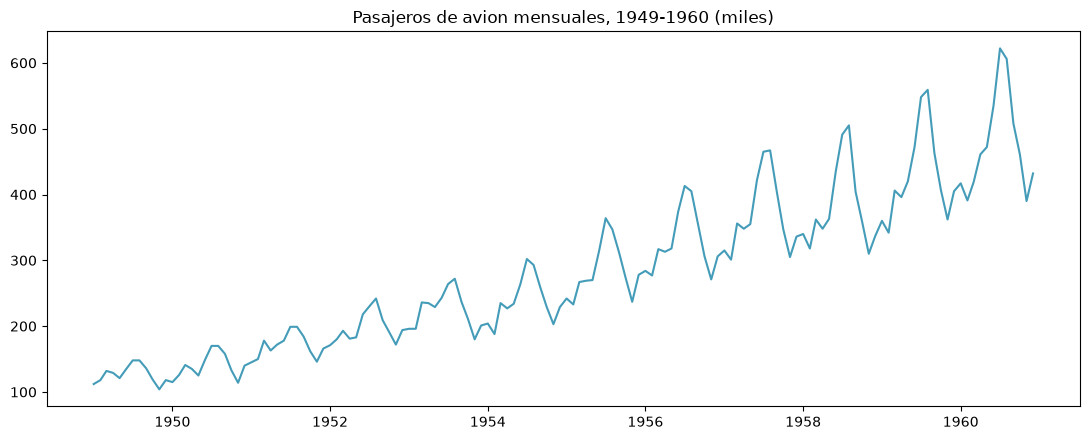

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(airline.index, airline.passengers, color='#449cb9')
ax.set_title('Pasajeros de avion mensuales, 1949-1960 (miles)')
plt.tight_layout()
plt.savefig('airline_serie.png', dpi=130)
plt.show()

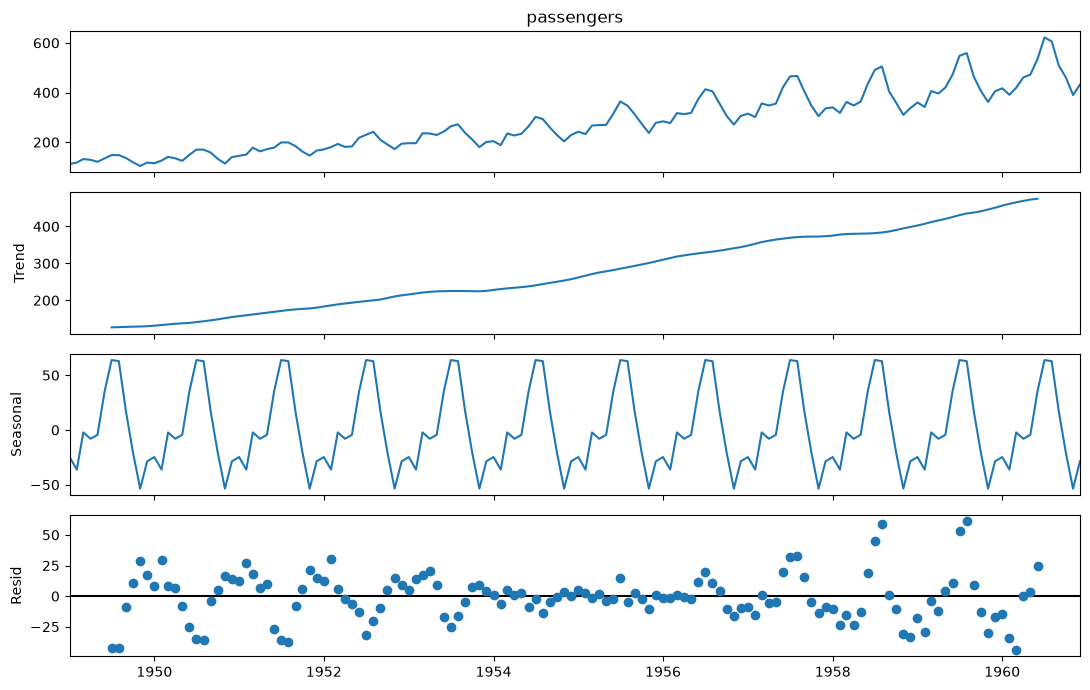

In [7]:
result_add = seasonal_decompose(airline['passengers'], model='additive')
fig = result_add.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.savefig('airline_decompose_additive.png', dpi=130)
plt.show()

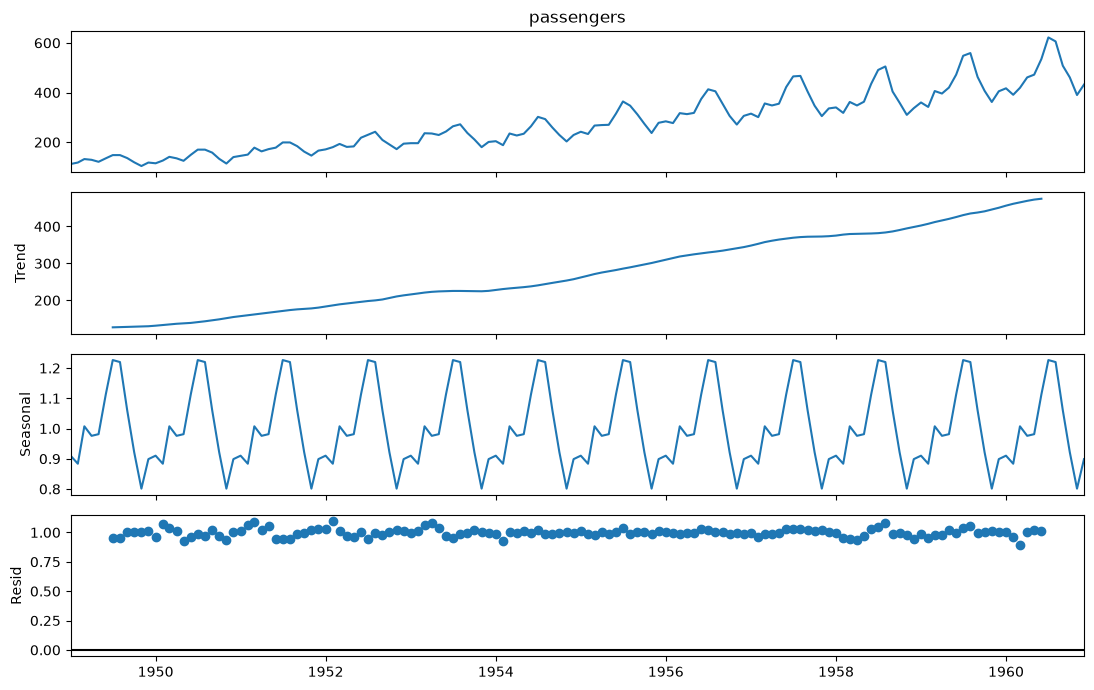

In [8]:
result_mult = seasonal_decompose(airline['passengers'], model='multiplicative')
fig = result_mult.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.savefig('airline_decompose_multiplicative.png', dpi=130)
plt.show()

**Como leer la diferencia aditivo vs multiplicativo**: en el modelo aditivo, el residuo de la descomposicion crece claramente con el tiempo (la amplitud de las oscilaciones del residuo es mayor al final que al principio) -- señal de que la estacionalidad real NO es de amplitud constante, sino proporcional al nivel de la serie. En el modelo multiplicativo el residuo se mantiene mas estable en amplitud a lo largo de toda la serie: es el modelo que de verdad encaja con estos datos.

**Entregable**: reproduce estas celdas. Compara a simple vista el panel "Resid" de la descomposicion aditiva contra el de la multiplicativa y confirma cual de las dos tiene un residuo con amplitud mas estable en el tiempo.